# Explainable AI (XAI) Analysis

This notebook applies explainable AI techniques to interpret the machine learning models developed for PCOS prediction.

The analysis focuses on:

- SHAP (SHapley Additive exPlanations)
- LIME (Local Interpretable Model-agnostic Explanations)

These techniques help explain how features influenced model predictions and improve transparency in healthcare-focused AI systems.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Explainable AI libraries
import shap
from lime.lime_tabular import LimeTabularExplainer

c:\Users\c7271492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load cleaned dataset

df = pd.read_csv("../data/processed/pcos_cleaned.csv")

# Display first rows
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,1.0,0,110,80,3,3,18.0,18.0,8.5
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,0.0,0,120,70,3,5,15.0,14.0,3.7
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,1,1.0,0,120,80,13,15,18.0,20.0,10.0
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,0.0,0,120,70,2,2,15.0,14.0,7.5
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,0.0,0,120,80,3,4,16.0,14.0,7.0


In [5]:
# Define target variable

y = df["PCOS (Y/N)"]

# Define feature variables
X = df.drop("PCOS (Y/N)", axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Convert object columns to numeric

X_train["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_train["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_test["II    beta-HCG(mIU/mL)"] = pd.to_numeric(
    X_test["II    beta-HCG(mIU/mL)"],
    errors="coerce"
)

X_train["AMH(ng/mL)"] = pd.to_numeric(
    X_train["AMH(ng/mL)"],
    errors="coerce"
)

X_test["AMH(ng/mL)"] = pd.to_numeric(
    X_test["AMH(ng/mL)"],
    errors="coerce"
)

# Fill missing values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())


# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data prepared successfully.")

Data prepared successfully.


# Final Model Selection

Random Forest was selected as the final model for explainability analysis because it achieved the strongest overall predictive performance during evaluation.

In [6]:
# Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


# SHAP Analysis

SHAP (SHapley Additive exPlanations) was used to explain how features influenced the Random Forest model predictions.

SHAP helps identify:
- the most important features
- positive and negative feature influence
- how individual predictions were formed

In [7]:
# Create SHAP explainer

explainer = shap.TreeExplainer(rf_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values generated successfully.")

SHAP values generated successfully.


# SHAP Feature Importance

The SHAP summary plot shows which features had the greatest influence on the Random Forest model predictions.

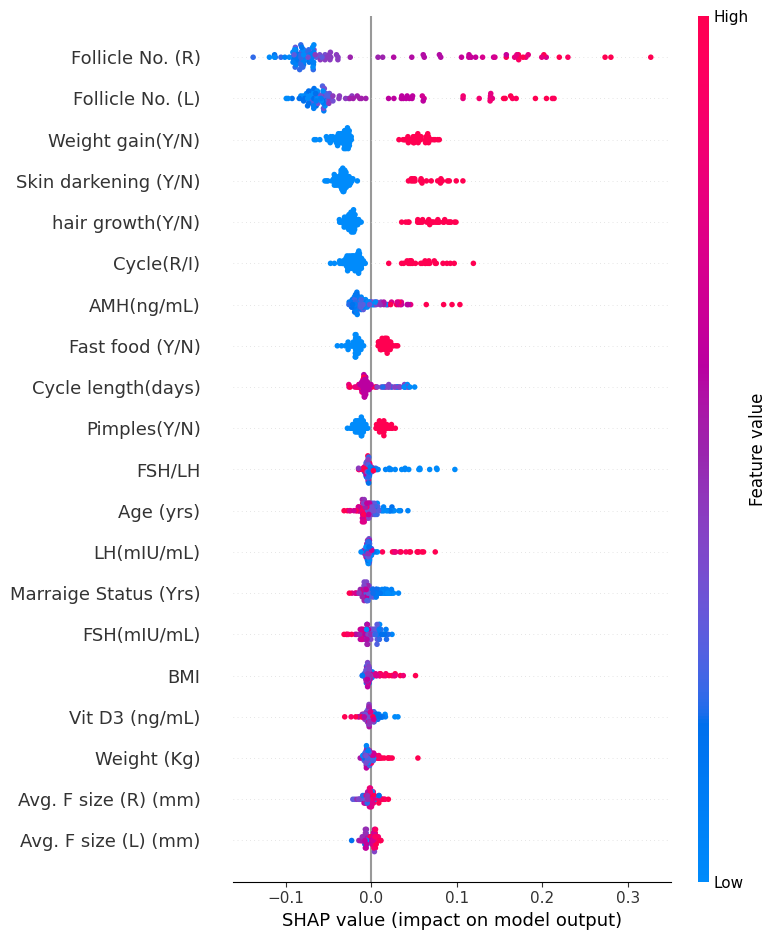

In [8]:
# SHAP summary plot

shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    feature_names=X.columns
)